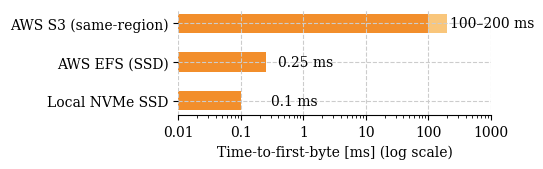

In [1]:
import matplotlib.pyplot as plt
import numpy as np

tiers   = ["Local NVMe SSD", "AWS EFS (SSD)", "AWS S3 (same‑region)"]
lat_ms  = np.array([0.1, 0.25, 100])
err_high = 100

color_main = "#f28e2b"
color_fade = "#f9c67b"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.color": "0.8",
})

fig, ax = plt.subplots(figsize=(5.4, 1.8))
ax.set_xscale('log')

bar_container = ax.barh(tiers[:2], lat_ms[:2], height=0.5, color=color_main)

bar_base = ax.barh(tiers[2], lat_ms[2], height=0.5, color=color_main)
ax.barh(tiers[2], err_high, left=lat_ms[2], height=0.5, color=color_fade)

ax.text(lat_ms[0]*3, bar_container[0].get_y()+0.25, "0.1 ms", va="center")
ax.text(lat_ms[1]*1.6, bar_container[1].get_y()+0.25, "0.25 ms",  va="center")
ax.text(200*1.1,        bar_base[0].get_y()+0.25, "100–200 ms", va="center")

ax.set_xlabel("Time‑to‑first‑byte [ms] (log scale)")
ax.set_xlim(0.01, 400)
ax.set_xticks([0.01, 0.1, 1, 10, 100, 1000])
ax.get_xaxis().set_major_formatter(lambda x, pos: f"{x:g}")

plt.tight_layout()
plt.savefig("latency_ladder.png")
# save as pdf
plt.savefig("latency_ladder.pdf")